# Notebook 01: Dataset Exploration and XGBoost Baseline

This notebook loads the **TabFormer** (IBM) credit card transaction dataset (~24M transactions), creates temporal train/val/test splits, and trains a GPU-accelerated **XGBoost baseline** for fraud detection.

**Primary metric**: Average Precision (AUPRC), more informative than AUROC at realistic fraud rates (~0.1%).

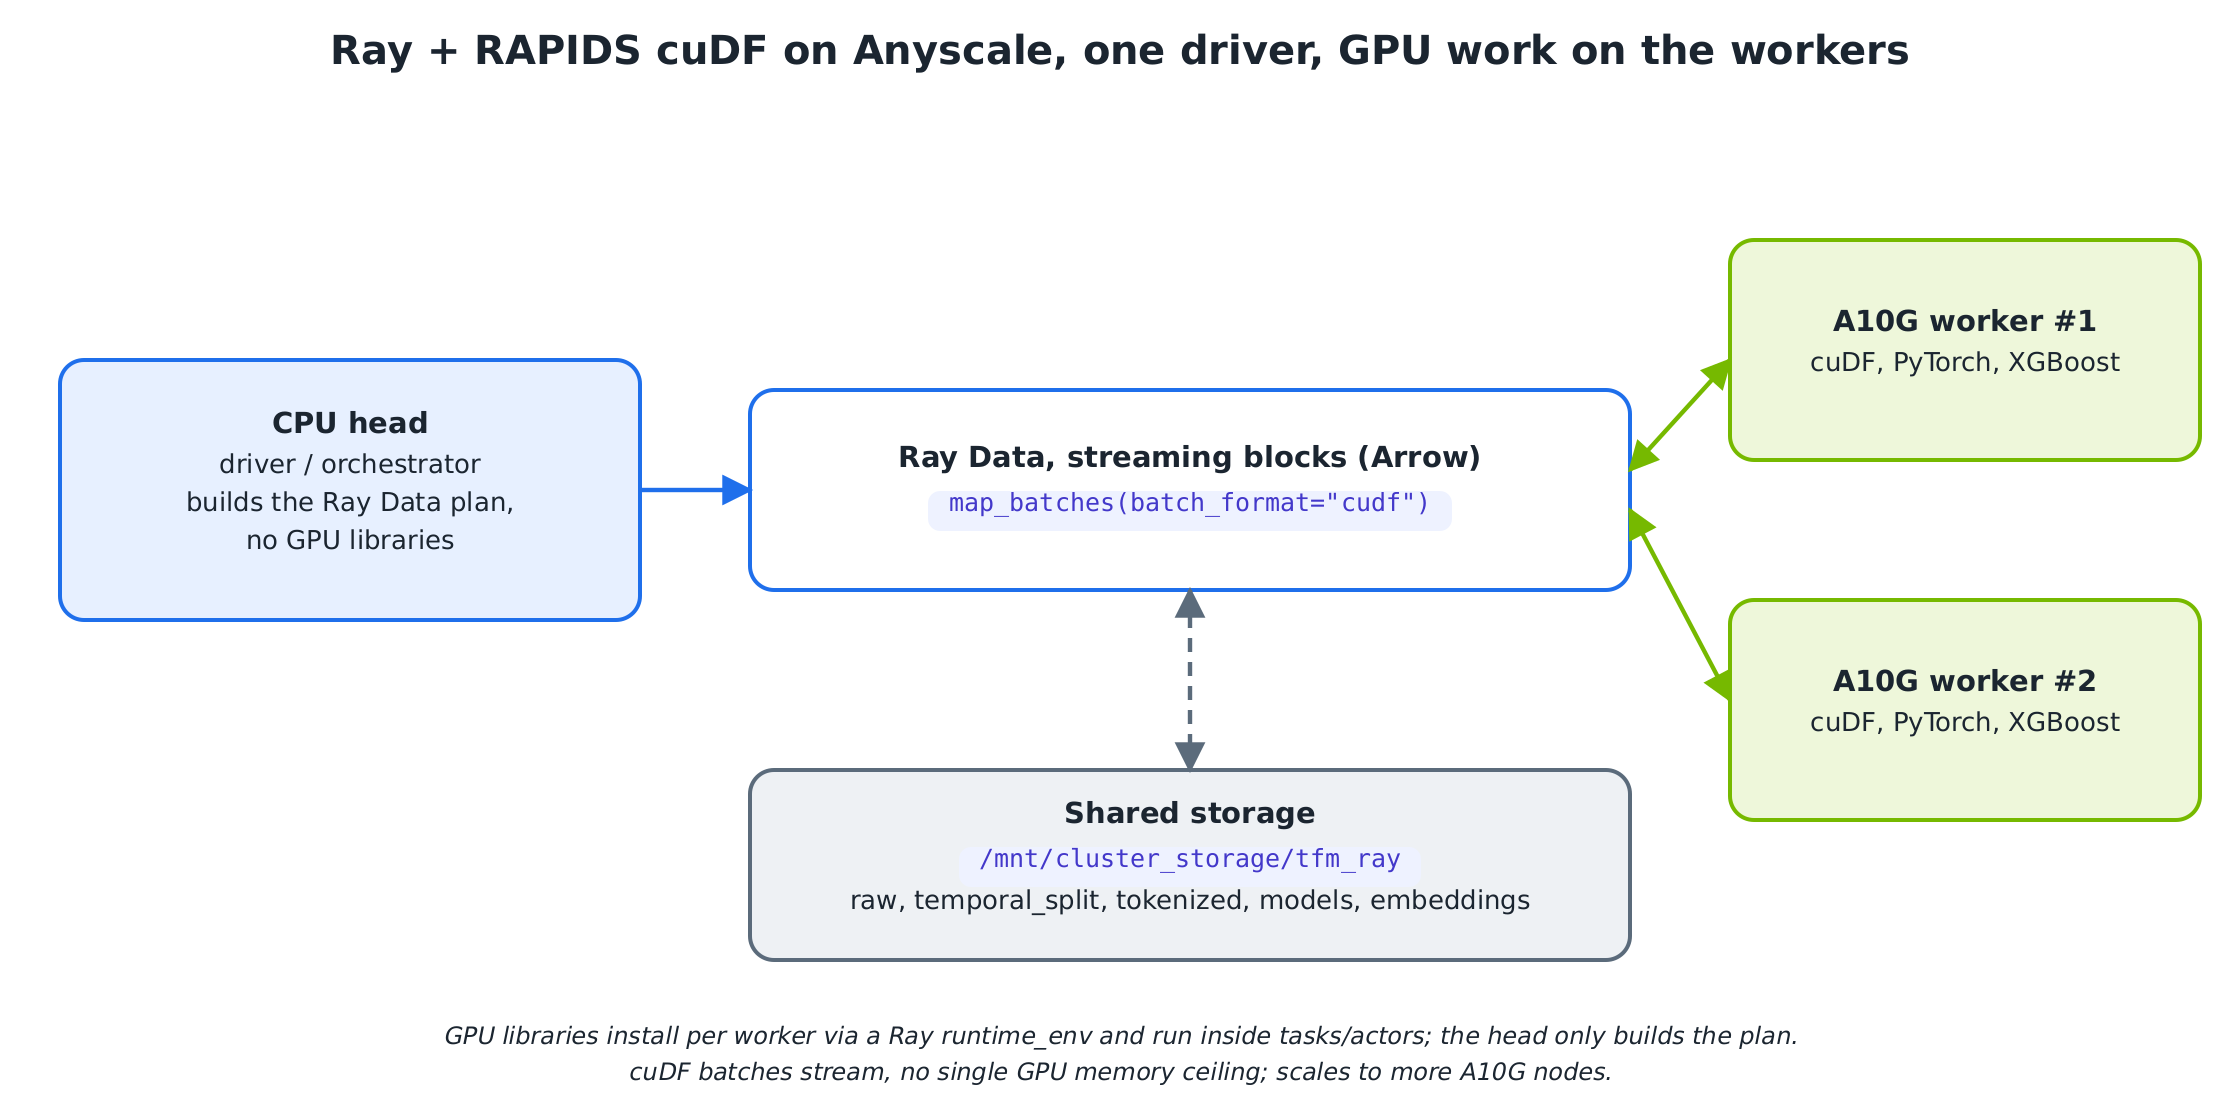

| Step | Original (single GPU) | Ray (this notebook) |
|------|-----------------------|-----------------------------|
| Ingest | `cudf.read_csv` (must fit in VRAM) | `ray.data.read_parquet` (streamed, any size) |
| Feature engineering | cuDF on one GPU | **same cuDF**, via `map_batches(batch_format="cudf", num_gpus=1)` across workers |
| Temporal split | cuDF groupby + boolean masks | Ray Data `groupby` / expression `filter` (distributed) |
| EDA (4-panel) | cuDF aggregations on one node | Ray Data `groupby` aggregations (distributed) |
| XGBoost | single-GPU `XGBClassifier(device=cuda)` | same model, **scheduled by Ray** on a GPU worker |

**Data:** a self-contained synthetic generator reproduces the exact TabFormer
schema; set `TFM_REAL_CSV` to use the real `card_transaction.v1.csv` instead.

## Outline

0. Setup and Imports
1. Load Raw TabFormer Dataset
2. Temporal Split
3. Data Visualization
4. Create Training and Evaluation Datasets
5. XGBoost Baseline
6. Conclusion

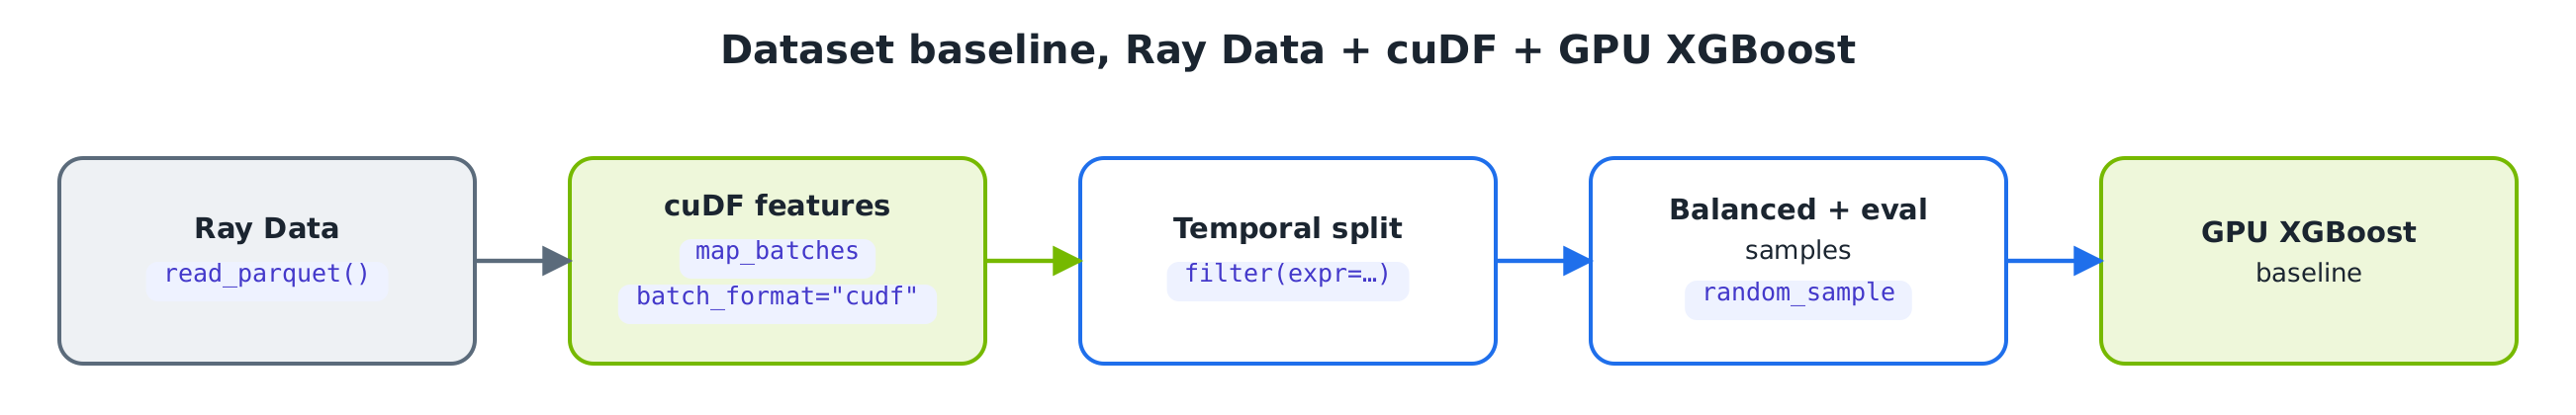

## `Step 0`: Setup and Imports

The original imported cuDF, XGBoost and torch **on the head**. The Ray's
golden rule is the opposite: the **CPU head only orchestrates Ray** — every GPU
library (cuDF / torch / xgboost) is imported and run *inside Ray tasks/actors on
the A10G workers*, with the deps shipped per-worker via a Ray `runtime_env`. So
here we just connect to the cluster.

In [1]:
import time
from pathlib import Path

import ray
from src import ray_common as C

if not ray.is_initialized():
    # JOB_RUNTIME_ENV ships the src package to every node (code only).
    ray.init(address="auto", runtime_env=C.JOB_RUNTIME_ENV)

print("Ray cluster resources:")
res = ray.cluster_resources()
print(f"  CPUs: {res.get('CPU', 0):.0f} | GPUs: {res.get('GPU', 0):.0f}")
print(f"Shared data root: {C.DATA_ROOT}")

2026-06-10 18:34:45,094	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 10.0.128.242:6379...
2026-06-10 18:34:45,139	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at https://session-qpwcx5l3g8cwbw1p61s98gvrp4.i.anyscaleuserdata.com 
2026-06-10 18:34:45,150	INFO packaging.py:691 -- Creating a file package for local module '/home/ray/default_cld_g54aiirwj1s8t9ktgzikqur41k/transaction-foundation-model-with-ray/src'.
2026-06-10 18:34:45,155	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_ccf1119ca1eb3c82.zip' (0.07MiB) to Ray cluster...
2026-06-10 18:34:45,156	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_ccf1119ca1eb3c82.zip'.
2026-06-10 18:34:45,160	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_d806cdd50fe9b5ae334af86189d795eac9f66c0d.zip' (2.14MiB) to Ray cluster...
2026-06-10 18:34:45,167	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_d806cdd50fe9b5ae334af861

Ray cluster resources:
  CPUs: 128 | GPUs: 2
Shared data root: /mnt/cluster_storage/tfm_ray


/home/ray/anaconda3/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


## `Step 1`: Load Raw TabFormer Dataset

The [TabFormer](https://github.com/IBM/TabFormer) dataset contains ~24.4M synthetic credit card transactions across 2,000 users (10 cards each), spanning 2002--2019, with a ~0.12% fraud rate.

In [2]:
import os
from src import data_gen

RAW = C.RAW_DIR / "transactions.parquet"
if not RAW.exists():
    real_csv = os.environ.get("TFM_REAL_CSV")
    if real_csv:
        n = data_gen.materialize_real(real_csv, RAW)
        print(f"Materialized REAL dataset: {n:,} rows -> {RAW}")
    else:
        n = data_gen.materialize_synthetic(RAW, n_users=2000, avg_txns_per_user=750, seed=42)
        print(f"Generated synthetic dataset: {n:,} rows -> {RAW}")
else:
    print(f"Dataset already present: {RAW}")

# Streamed ingest — no single-GPU memory ceiling.
ds = ray.data.read_parquet(str(RAW))
n_total = ds.count()
print(f"\nTotal transactions: {n_total:,}")
print("Schema:")
print(ds.schema())

Dataset already present: /mnt/cluster_storage/tfm_ray/raw/transactions.parquet


2026-06-10 18:34:50,147	INFO logging.py:416 -- Registered dataset logger for dataset dataset_1_0
2026-06-10 18:34:50,208	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_1_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:34:50,208	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_1_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[MapBatches(count_rows)]
2026-06-10 18:34:50,211	WARNING resource_manager.py:169 -- ⚠️  Ray's object store is configured to use only 28.1% of available memory (179.8GiB out of 640.0GiB total). For optimal Ray Data performance, we recommend setting the object store to at least 50% of available memory. You can do this by setting the 'object_store_memory' parameter when calling ray.init() or by setting the RAY_DEFAULT_OBJECT_STORE_MEMORY_PROPORTION environment variable.
2026-06-10 18:34:50,214	INFO __init__.py:56 -- Progress will be logged bec


Total transactions: 24,386,900
Schema:
Column          Type
------          ----
User            int64
Card            int64
Year            int64
Month           int64
Day             int64
Time            string
Amount          string
Use Chip        string
Merchant Name   int64
Merchant City   string
Merchant State  string
Zip             double
MCC             int64
Errors?         string
Is Fraud?       string


## `Step 2`: Temporal Split

We create an 80/10/10 temporal split based on cumulative transaction counts. This ensures the test set contains the most recent transactions, preventing data leakage.


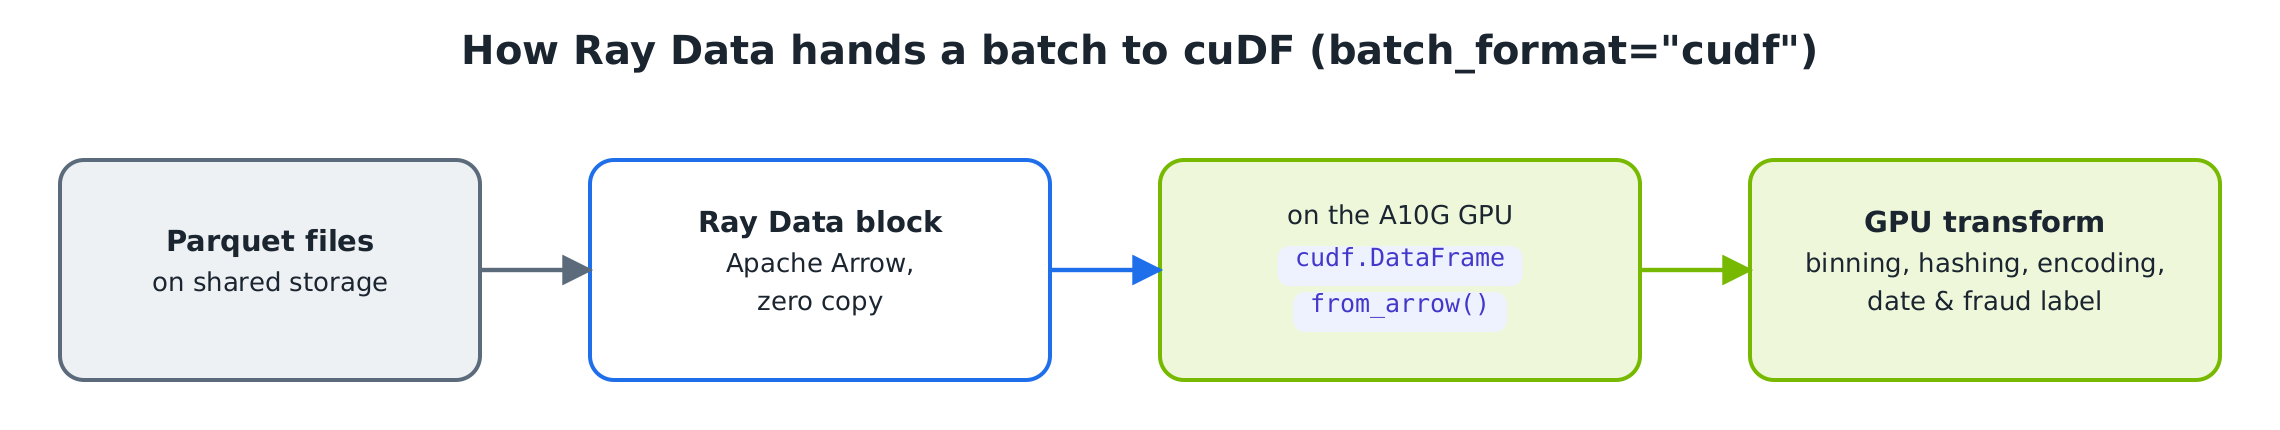

In [3]:
# GPU feature engineering with cuDF, streamed by Ray Data 
class GPUFeatureEngineer:
    def __call__(self, batch):                      # batch is a cudf.DataFrame
        gdf = batch
        gdf.columns = [c.strip() for c in gdf.columns]
        y = gdf["Year"].astype("str")
        m = gdf["Month"].astype("str").str.zfill(2)
        d = gdf["Day"].astype("str").str.zfill(2)
        gdf["date"] = y + "-" + m + "-" + d
        isf = gdf["Is Fraud?"]
        gdf["is_fraud"] = ((isf == "Yes") | (isf == "1")).astype("int32")
        return gdf

ds = ds.map_batches(
    GPUFeatureEngineer,
    batch_size=524_288,
    compute=ray.data.ActorPoolStrategy(size=2),    # one actor per A10G worker
    num_gpus=1,
    batch_format="cudf",                           # Ray Data delivers cudf.DataFrame
    runtime_env=C.GPU_RUNTIME_ENV,
).materialize()

# Distributed per-day counts -> small pandas frame on the head.
daily = ds.groupby("date").count().to_pandas()
count_col = [c for c in daily.columns if c != "date"][0]
daily = daily.sort_values("date").reset_index(drop=True)
daily["cum"] = daily[count_col].cumsum()
total = int(daily["cum"].iloc[-1])

def cutoff(ratio):
    return daily.loc[daily["cum"] >= total * ratio, "date"].iloc[0]

train_cut, test_cut = cutoff(0.8), cutoff(0.9)
print(f"Train/Val cutoff: {train_cut}   Val/Test cutoff: {test_cut}")

2026-06-10 18:37:23,675	INFO logging.py:416 -- Registered dataset logger for dataset dataset_3_0
2026-06-10 18:37:23,680	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_3_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:37:23,681	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_3_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> ActorPoolMapOperator[MapBatches(GPUFeatureEngineer)]
{"asctime":"2026-06-10 18:37:23,707","levelname":"E","message":"Actor with class name: 'MapWorker(MapBatches(GPUFeatureEngineer))' and ID: '43fe33d4aebf4316fd72932e03000000' has constructor arguments in the object store and max_restarts > 0. If the arguments in the object store go out of scope or are lost, the actor restart will fail. See https://github.com/ray-project/ray/issues/53727 for more details.","filename":"core_worker.cc","lineno":2194}
2026-06-10 18:37:23,842	INF

Train/Val cutoff: 2017-05-14   Val/Test cutoff: 2018-10-12


### Dataset Summary

The original printed this summary from the single in-GPU cuDF frame. Here the
same numbers come from **distributed Ray Data aggregations** (`groupby().count()`,
`min`/`max`, predicate-filter `count`) that run across the cluster — identical
whether the data is 1.5M synthetic rows or the full ~24M-row real CSV.

In [4]:
# Distinct users, overall fraud rate and the year span, Ray Data aggregations.
n_users = ds.groupby("User").count().count()      # rows after groupby == #users
n_fraud_all = ds.filter(expr="is_fraud == 1").count()
yr_min, yr_max = ds.min("Year"), ds.max("Year")

print("Dataset Summary:")
print(f"  Rows:    {n_total:,}")
print(f"  Users:   {n_users:,}")
print(f"  Fraud:   {n_fraud_all:,} / {n_total:,} ({n_fraud_all / n_total:.4%})")
print(f"  Years:   {yr_min} to {yr_max}")

2026-06-10 18:39:06,364	INFO logging.py:416 -- Registered dataset logger for dataset dataset_7_0
2026-06-10 18:39:06,367	INFO hash_aggregate.py:161 -- Estimated memory requirement for aggregating aggregator (partitions=24, aggregators=24, dataset (estimate)=3.4GiB): shuffle=146.3MiB, output=146.3MiB, total=292.6MiB, 
2026-06-10 18:39:06,369	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_7_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:39:06,369	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_7_0: InputDataBuffer[Input] -> HashAggregateOperator[HashAggregate(key_columns=('User',), num_partitions=24)] -> TaskPoolMapOperator[Project] -> AggregateNumRows[AggregateNumRows]
2026-06-10 18:39:06,407	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_7_0 =======
2026-06-10 18:39:06,408	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-06-10 18:39:06,408	INFO logging_progress.py:22

Dataset Summary:
  Rows:    24,386,900
  Users:   2,000
  Fraud:   29,757 / 24,386,900 (0.1220%)
  Years:   1991 to 2020


In [5]:
# Expression filters -> predicate pushdown / vectorized (no per-row Python UDF), (similar to cuDF boolean masks)
train_ds = ds.filter(expr=f"date < '{train_cut}'").materialize()
val_ds   = ds.filter(expr=f"date >= '{train_cut}' and date < '{test_cut}'").materialize()
test_ds  = ds.filter(expr=f"date >= '{test_cut}'").materialize()

import shutil
HELPER_COLS = ["date", "is_fraud"]                       # added for split/labels; dropped on write
def write_split(d, name):
    p = C.SPLIT_DIR / name
    shutil.rmtree(p, ignore_errors=True)                 # idempotent re-runs
    d.drop_columns(HELPER_COLS).write_parquet(str(p))    # keep original TabFormer schema

def fraud_rate(d):
    n = d.count()
    f = d.filter(expr="is_fraud == 1").count()
    return n, f, (f / n if n else 0.0)

print(f"{'Split':<6}{'Rows':>12}{'Fraud':>8}{'Rate':>10}")
for name, d in [("Train", train_ds), ("Val", val_ds), ("Test", test_ds)]:
    n, f, r = fraud_rate(d)
    write_split(d, name.lower())
    print(f"{name:<6}{n:>12,}{f:>8,}{r:>9.4%}")
print(f"\nSplits written under {C.SPLIT_DIR}")

/tmp/ipykernel_52197/2604131995.py:2: DeprecationWarning: String expressions are deprecated and will be removed in a future version. Use predicate expressions from ray.data.expressions instead. For example: from ray.data.expressions import col; ds.filter(expr=col('column_name') > 5)
  train_ds = ds.filter(expr=f"date < '{train_cut}'").materialize()
2026-06-10 18:39:12,303	INFO logging.py:416 -- Registered dataset logger for dataset dataset_15_0
2026-06-10 18:39:12,305	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_15_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:39:12,305	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_15_0: InputDataBuffer[Input] -> TaskPoolMapOperator[Filter(col('date') < '2017-05-14')]
2026-06-10 18:39:12,328	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_15_0 =======
2026-06-10 18:39:12,329	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-06-10 

Split         Rows   Fraud      Rate


2026-06-10 18:39:14,666	INFO logging.py:416 -- Registered dataset logger for dataset dataset_27_0
2026-06-10 18:39:14,668	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_27_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:39:14,669	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_27_0: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(drop_columns)->Write]
2026-06-10 18:39:14,692	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_27_0 =======
2026-06-10 18:39:14,693	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-06-10 18:39:14,693	INFO logging_progress.py:227 -- Active & requested resources: 0/128 CPU, 0.0B/72.0GiB object store
2026-06-10 18:39:14,694	INFO logging_progress.py:181 -- 
2026-06-10 18:39:14,694	INFO logging_progress.py:231 -- MapBatches(drop_columns)->Write: 0/1
2026-06-10 18:39:14,694	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks

Train   19,508,123  24,924  0.1278%


2026-06-10 18:39:16,759	INFO logging.py:416 -- Registered dataset logger for dataset dataset_33_0
2026-06-10 18:39:16,761	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_33_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:39:16,762	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_33_0: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(drop_columns)->Write]
2026-06-10 18:39:16,785	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_33_0 =======
2026-06-10 18:39:16,786	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-06-10 18:39:16,787	INFO logging_progress.py:227 -- Active & requested resources: 0/128 CPU, 0.0B/72.0GiB object store
2026-06-10 18:39:16,787	INFO logging_progress.py:181 -- 
2026-06-10 18:39:16,788	INFO logging_progress.py:231 -- MapBatches(drop_columns)->Write: 0/1
2026-06-10 18:39:16,788	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks

Val      2,435,982   2,109  0.0866%


2026-06-10 18:39:17,947	INFO logging.py:416 -- Registered dataset logger for dataset dataset_39_0
2026-06-10 18:39:17,949	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_39_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:39:17,950	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_39_0: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(drop_columns)->Write]
2026-06-10 18:39:17,972	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_39_0 =======
2026-06-10 18:39:17,973	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-06-10 18:39:17,973	INFO logging_progress.py:227 -- Active & requested resources: 0/128 CPU, 0.0B/72.0GiB object store
2026-06-10 18:39:17,973	INFO logging_progress.py:181 -- 
2026-06-10 18:39:17,974	INFO logging_progress.py:231 -- MapBatches(drop_columns)->Write: 0/1
2026-06-10 18:39:17,974	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks

Test     2,442,795   2,724  0.1115%

Splits written under /mnt/cluster_storage/tfm_ray/temporal_split


## `Step 3`: Data Visualization

The original built a 4-panel EDA figure from the in-GPU cuDF frame. 

We reproduce the **same four views**: fraud class imbalance, transactions-per-user, the transaction time series with the temporal-split boundaries, and fraud rate by merchant category (MCC), but the per-group aggregates come from **distributed Ray Data `groupby`** over the training split. 

Only the small grouped results land on the head for plotting. The figure is shown inline and also saved to shared storage.

/tmp/ipykernel_52197/3429625138.py:7: DeprecationWarning: String expressions are deprecated and will be removed in a future version. Use predicate expressions from ray.data.expressions instead. For example: from ray.data.expressions import col; ds.filter(expr=col('column_name') > 5)
  f_train = train_ds.filter(expr="is_fraud == 1").count()
2026-06-10 18:39:20,647	INFO logging.py:416 -- Registered dataset logger for dataset dataset_42_0
2026-06-10 18:39:20,650	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_42_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:39:20,650	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_42_0: InputDataBuffer[Input] -> TaskPoolMapOperator[Filter(col('is_fraud') == 1)->Project] -> AggregateNumRows[AggregateNumRows]
2026-06-10 18:39:20,677	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_42_0 =======
2026-06-10 18:39:20,678	INFO logging_progress.py:225 --

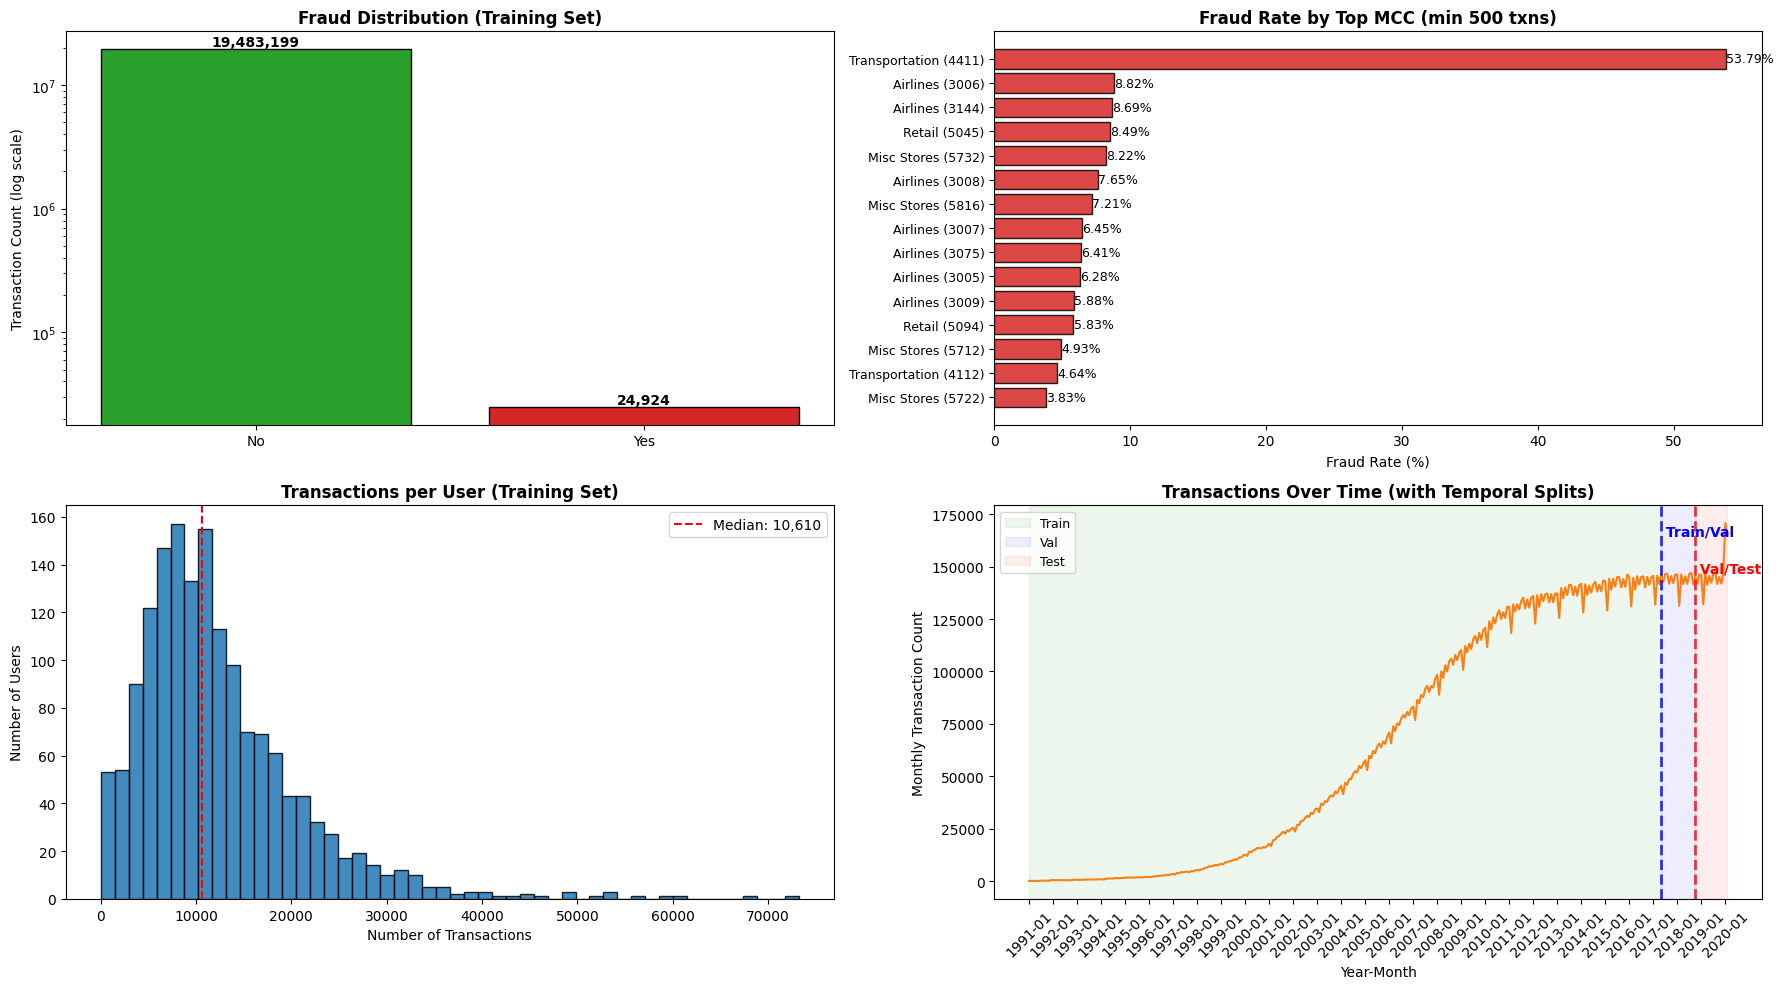

Saved /mnt/cluster_storage/tfm_ray/outputs/nb01_eda.png


In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Panel inputs from distributed Ray Data aggregations
n_train = train_ds.count()
f_train = train_ds.filter(expr="is_fraud == 1").count()
tpu = train_ds.groupby("User").count().to_pandas()                 # txns per user
tpu_counts = tpu[[c for c in tpu.columns if c != "User"][0]].to_numpy()
mcc_rate = train_ds.groupby("MCC").mean("is_fraud").to_pandas()    # fraud rate / MCC
mcc_cnt  = train_ds.groupby("MCC").count().to_pandas()
rate_col = [c for c in mcc_rate.columns if c != "MCC"][0]
cnt_col  = [c for c in mcc_cnt.columns if c != "MCC"][0]
mcc = mcc_rate.merge(mcc_cnt, on="MCC")
# monthly counts over time from the distributed per-day `daily` frame
m = daily.copy(); m["period"] = m["date"].str[:7]
monthly = (m.groupby("period", as_index=False)[count_col].sum()
             .sort_values("period").reset_index(drop=True))

# MCC -> industry label mapping (same table as the original NB01 EDA).
MCC_INDUSTRY_RANGES = [
    (0, 1499, "Agricultural"), (1500, 2999, "Contracted"),
    (3000, 3299, "Airlines"), (3300, 3499, "Car Rental"),
    (3500, 3999, "Lodging"), (4000, 4799, "Transportation"),
    (4800, 4999, "Utilities"), (5000, 5599, "Retail"),
    (5600, 5699, "Clothing"), (5700, 7299, "Misc Stores"),
    (7300, 7999, "Business Services"), (8000, 8999, "Professional"),
    (9000, 9999, "Government"),
]
def mcc_label(code):
    code = int(code)
    for lo, hi, name in MCC_INDUSTRY_RANGES:
        if lo <= code <= hi:
            return f"{name} ({code})"
    return str(code)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1) Fraud distribution (train) — extreme imbalance, log scale
ax1 = axes[0, 0]
vals = [n_train - f_train, f_train]
ax1.bar(["No", "Yes"], vals, color=["#2ca02c", "#d62728"], edgecolor="black")
ax1.set_yscale("log"); ax1.set_ylabel("Transaction Count (log scale)")
ax1.set_title("Fraud Distribution (Training Set)", fontweight="bold")
for i, v in enumerate(vals):
    ax1.text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")

# 2) Transactions per user (train)
ax2 = axes[1, 0]
ax2.hist(tpu_counts, bins=50, color="#1f77b4", edgecolor="black", alpha=0.85)
med = int(np.median(tpu_counts))
ax2.axvline(med, color="red", ls="--", lw=1.5, label=f"Median: {med:,}")
ax2.set_title("Transactions per User (Training Set)", fontweight="bold")
ax2.set_xlabel("Number of Transactions"); ax2.set_ylabel("Number of Users"); ax2.legend()

# 3) Transactions over time with temporal-split boundaries + shaded regions
ax3 = axes[1, 1]
ax3.plot(range(len(monthly)), monthly[count_col].to_numpy(), color="#ff7f0e", lw=1.5)
periods = monthly["period"].tolist()
tc_x = periods.index(train_cut[:7]) if train_cut[:7] in periods else None
vc_x = periods.index(test_cut[:7]) if test_cut[:7] in periods else None
if tc_x is not None:
    ax3.axvline(tc_x, color="blue", ls="--", lw=2, alpha=0.8)
    ax3.text(tc_x, ax3.get_ylim()[1] * 0.95, " Train/Val", color="blue", fontweight="bold", va="top")
if vc_x is not None:
    ax3.axvline(vc_x, color="red", ls="--", lw=2, alpha=0.8)
    ax3.text(vc_x, ax3.get_ylim()[1] * 0.85, " Val/Test", color="red", fontweight="bold", va="top")
# Shaded Train / Val / Test bands (matches the original EDA).
if tc_x is not None and vc_x is not None:
    ax3.axvspan(0, tc_x, alpha=0.07, color="green", label="Train")
    ax3.axvspan(tc_x, vc_x, alpha=0.07, color="blue", label="Val")
    ax3.axvspan(vc_x, len(periods) - 1, alpha=0.07, color="red", label="Test")
    ax3.legend(loc="upper left", fontsize=9)
ticks = range(0, len(periods), 12)   # yearly ticks, like the original
ax3.set_xticks(list(ticks)); ax3.set_xticklabels([periods[i] for i in ticks], rotation=45)
ax3.set_title("Transactions Over Time (with Temporal Splits)", fontweight="bold")
ax3.set_ylabel("Monthly Transaction Count"); ax3.set_xlabel("Year-Month")

# 4) Fraud rate by top MCC (min volume)
ax4 = axes[0, 1]
min_txns = 500
mf = mcc[mcc[cnt_col] >= min_txns].copy()
mf["pct"] = mf[rate_col] * 100.0
mf = mf.sort_values("pct", ascending=False).head(15)
bar_colors = ["#d62728" if p > 1.0 else "#ff7f0e" for p in mf["pct"]]
ax4.barh(range(len(mf)), mf["pct"].to_numpy(), color=bar_colors, edgecolor="black", alpha=0.85)
ax4.set_yticks(range(len(mf)))
ax4.set_yticklabels([mcc_label(x) for x in mf["MCC"]], fontsize=9)
ax4.invert_yaxis(); ax4.set_xlabel("Fraud Rate (%)")
ax4.set_title(f"Fraud Rate by Top MCC (min {min_txns} txns)", fontweight="bold")
for i, p in enumerate(mf["pct"].to_numpy()):
    ax4.text(p + 0.02, i, f"{p:.2f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(C.OUTPUT_DIR / "nb01_eda.png", dpi=120)
plt.show()
print(f"Saved {C.OUTPUT_DIR / 'nb01_eda.png'}")

## `Step 4`: Create Training and Evaluation Datasets


The original cleaned the `Amount` field (strip `$` and `,`), extracted `Hour` from the `Time` column, and encoded the fraud target — all with cuDF on the head, then converted to pandas for modeling.

**There is no separate preprocessing cell here by design.** The same feature engineering is performed where the data already lives on a GPU worker, not on the head:

- The sortable `date` and the integer `is_fraud` target were produced by the **cuDF Ray Data stage in Section 2**.
- The remaining per-feature cleaning — `Amount` → float, `Hour` from `Time`, and ordinal encoding — runs **inside the Ray GPU task that trains XGBoost in Section 6**, so the encoder and model live on the same worker GPU and the head never imports cuDF, XGBoost or scikit-learn.

- **Balanced train** (`train_balanced`): all fraud + 39× sampled normal (~2.5% fraud) — reused by the XGBoost baseline here and by the foundation-model embeddings in NB04/05.
- **`val_eval` / `test_eval`**: **100k** stratified subsamples of val/test (preserving the ~0.1% fraud rate), matching the original blueprint's `EVAL_SAMPLES = 100_000`.

All built with Ray Data (`filter` + `random_sample` + `union`) and written to shared storage.


In [7]:
import numpy as np

# balanced training sample from the train split (expression filters) 
train_fraud = train_ds.filter(expr="is_fraud == 1").materialize()
train_normal = train_ds.filter(expr="is_fraud == 0").materialize()
n_fraud = train_fraud.count()
n_normal_target = min(train_normal.count(), n_fraud * 39)   # -> ~2.5% fraud
frac = min(1.0, n_normal_target / max(train_normal.count(), 1))
bal = train_fraud.union(train_normal.random_sample(frac, seed=42)).random_shuffle(seed=42)
write_split(bal, "train_balanced")
print(f"Balanced train: {bal.count():,} rows "
      f"({n_fraud:,} fraud = {n_fraud / max(bal.count(),1):.2%})")

# evaluation sets: 100k stratified subsamples 
EVAL_SAMPLES = 100_000
def make_eval(d, name):
    n = d.count()
    frac = min(1.0, EVAL_SAMPLES / max(n, 1))
    sub = d.random_sample(frac, seed=42).materialize()
    write_split(sub, name)
    nf = sub.filter(expr="is_fraud == 1").count()
    print(f"{name}: {sub.count():,} rows ({nf:,} fraud, {nf/max(sub.count(),1):.4%})")

make_eval(val_ds, "val_eval")
make_eval(test_ds, "test_eval")

/tmp/ipykernel_52197/1104668242.py:4: DeprecationWarning: String expressions are deprecated and will be removed in a future version. Use predicate expressions from ray.data.expressions instead. For example: from ray.data.expressions import col; ds.filter(expr=col('column_name') > 5)
  train_fraud = train_ds.filter(expr="is_fraud == 1").materialize()
2026-06-10 18:39:29,651	INFO logging.py:416 -- Registered dataset logger for dataset dataset_47_0
2026-06-10 18:39:29,653	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_47_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:39:29,654	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_47_0: InputDataBuffer[Input] -> TaskPoolMapOperator[Filter(col('is_fraud') == 1)]
2026-06-10 18:39:29,676	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_47_0 =======
2026-06-10 18:39:29,676	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-06-10 18:39

Balanced train: 996,068 rows (24,924 fraud = 2.50%)


2026-06-10 18:39:41,423	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_62_0 execution finished in 0.66 seconds
INFO:openlineage.client.client:OpenLineageClient will use `composite` transport
INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>
2026-06-10 18:39:41,631	INFO logging.py:416 -- Registered dataset logger for dataset dataset_66_0
2026-06-10 18:39:41,633	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_66_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:39:41,634	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_66_0: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(drop_columns)->Write]
2026-06-10 18:39:41,657	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_66_0 

val_eval: 99,400 rows (88 fraud, 0.0885%)


2026-06-10 18:39:42,761	INFO logging.py:416 -- Registered dataset logger for dataset dataset_75_0
2026-06-10 18:39:42,764	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_75_0. Full logs are in /tmp/ray/session_2026-06-10_15-54-26_041190_3241/logs/ray-data
2026-06-10 18:39:42,764	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_75_0: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(drop_columns)->Write]
2026-06-10 18:39:42,788	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_75_0 =======
2026-06-10 18:39:42,789	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-06-10 18:39:42,789	INFO logging_progress.py:227 -- Active & requested resources: 0/128 CPU, 0.0B/72.0GiB object store
2026-06-10 18:39:42,790	INFO logging_progress.py:181 -- 
2026-06-10 18:39:42,790	INFO logging_progress.py:231 -- MapBatches(drop_columns)->Write: 0/1
2026-06-10 18:39:42,791	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks

test_eval: 99,390 rows (99 fraud, 0.0996%)


## `Step 5`: XGBoost Baseline (GPU-Accelerated)

We train a GPU-accelerated XGBoost classifier on the **balanced** training sample with HPO-tuned hyperparameters, and evaluate on the **100k stratified** val/test subsets. We report both AUROC and Average Precision (AP) at ~0.1% fraud rate, AP is the more operationally meaningful metric.


In [8]:
import pandas as pd

FEATURE_COLS = ['User', 'Card', 'Year', 'Month', 'Day', 'Hour', 'Amount',
                'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State',
                'Zip', 'MCC']

XGB_PARAMS = dict(n_estimators=400, max_depth=8, learning_rate=0.0023,
                  colsample_bytree=0.95, min_child_weight=12, subsample=0.673,
                  reg_alpha=0.01, reg_lambda=0.001, random_state=42)


@ray.remote(num_gpus=1, runtime_env=C.GPU_RUNTIME_ENV)
def train_xgb_gpu(train_pdf, val_pdf, test_pdf, feature_cols, params):
    import numpy as np, time
    import xgboost as xgb
    from sklearn.preprocessing import OrdinalEncoder
    from sklearn.compose import make_column_transformer, make_column_selector
    from sklearn.metrics import roc_auc_score, average_precision_score

    def prep(df):
        df = df.copy()
        for c in df.columns:
            dt = str(df[c].dtype)
            if dt.startswith("string"):
                df[c] = df[c].astype(object).where(df[c].notna(), np.nan)   # pd.NA -> np.nan
            elif dt in ("Float64", "Float32", "Int64", "Int32"):
                df[c] = df[c].astype("float64")
        df["Hour"] = df["Time"].str.split(":", n=1, expand=True)[0].astype(int)
        df["Amount"] = df["Amount"].str.replace("$", "", regex=False).str.replace(",", "").astype(float)
        y = ((df["Is Fraud?"] == "Yes") | (df["Is Fraud?"] == "1")).astype(int).values
        return df[feature_cols], y

    Xtr, ytr = prep(train_pdf); Xva, yva = prep(val_pdf); Xte, yte = prep(test_pdf)
    pre = make_column_transformer(
        (OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
         make_column_selector(dtype_include=["object", "category"])),
        remainder="passthrough")
    Xtr = pre.fit_transform(Xtr); Xva = pre.transform(Xva); Xte = pre.transform(Xte)

    t0 = time.time()
    clf = xgb.XGBClassifier(**params, tree_method="hist", device="cuda",
                            early_stopping_rounds=20, eval_metric="auc")
    clf.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)

    pv = clf.predict_proba(Xva)[:, 1]; pt = clf.predict_proba(Xte)[:, 1]
    return {
        "gpu": __import__("torch").cuda.get_device_name(0),
        "train_time_s": round(time.time() - t0, 1),
        "best_iteration": int(clf.best_iteration),
        "val_auc": float(roc_auc_score(yva, pv)), "val_ap": float(average_precision_score(yva, pv)),
        "test_auc": float(roc_auc_score(yte, pt)), "test_ap": float(average_precision_score(yte, pt)),
    }


# Read the (small) frames on the head and hand them to the GPU task.
train_pdf = pd.read_parquet(C.SPLIT_DIR / "train_balanced")
val_pdf   = pd.read_parquet(C.SPLIT_DIR / "val_eval")
test_pdf  = pd.read_parquet(C.SPLIT_DIR / "test_eval")
print(f"Training XGBoost on a GPU worker: train={len(train_pdf):,} val={len(val_pdf):,} test={len(test_pdf):,}")

metrics_baseline = ray.get(train_xgb_gpu.remote(train_pdf, val_pdf, test_pdf, FEATURE_COLS, XGB_PARAMS))
print("\n=== XGBoost baseline (13d raw features) ===")
for k, v in metrics_baseline.items():
    print(f"  {k}: {v}")

Training XGBoost on a GPU worker: train=996,068 val=99,400 test=99,390


(train_xgb_gpu pid=42964, ip=10.0.157.18) /tmp/ray/session_2026-06-10_15-54-26_041190_3241/runtime_resources/pip/7d66ca76eb8d1ea46a6b5e27dc4217dc2113d4dc/virtualenv/lib/python3.12/site-packages/xgboost/core.py:729: UserWarning: [18:41:24] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
(train_xgb_gpu pid=42964, ip=10.0.157.18) Potential solutions:
(train_xgb_gpu pid=42964, ip=10.0.157.18) - Use a data structure that matches the device ordinal in the booster.
(train_xgb_gpu pid=42964, ip=10.0.157.18) - Set the device for booster before call to inplace_predict.
(train_xgb_gpu pid=42964, ip=10.0.157.18) 
(train_xgb_gpu pid=42964, ip=10.0.157.18) This warning will only be shown once.
(train_xgb_gpu pid=42964, ip=10.0.157.18) 
(train_xgb_gpu pid=42964, ip=10.0.157.18)   return func(**kwargs)



=== XGBoost baseline (13d raw features) ===
  gpu: NVIDIA A10G
  train_time_s: 3.7
  best_iteration: 0
  val_auc: 0.9882909187940301
  val_ap: 0.1976297061353383
  test_auc: 0.9825065776964741
  test_ap: 0.20185776657018162


## `Step 6`: Baseline Reference for NB05

Keep this notebook's XGBoost baseline as the anchor point for the downstream
comparison in NB05 (embeddings-only and combined raw+embedding models).

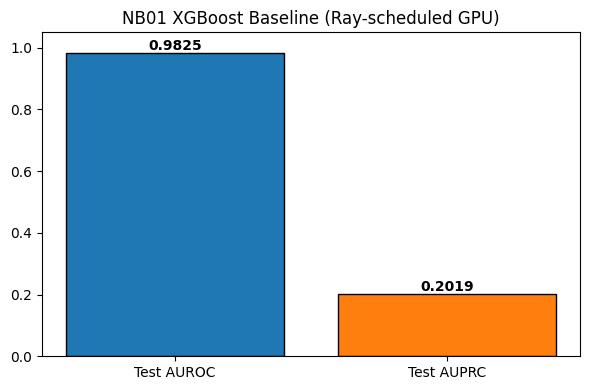

Saved /mnt/cluster_storage/tfm_ray/outputs/nb01_baseline.png

Baseline AUPRC=0.2019  AUROC=0.9825
Keep these as the reference for NB05 (embeddings vs raw vs combined).


(autoscaler +17m12s) Tip: use `ray status` to view detailed cluster status. To disable these messages, set RAY_SCHEDULER_EVENTS=0.


In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
vals = [metrics_baseline["test_auc"], metrics_baseline["test_ap"]]
bars = ax.bar(["Test AUROC", "Test AUPRC"], vals, color=["#1f77b4", "#ff7f0e"], edgecolor="black")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")
ax.set_ylim(0, 1.05); ax.set_title("NB01 XGBoost Baseline (Ray-scheduled GPU)")
plt.tight_layout(); plt.savefig(C.OUTPUT_DIR / "nb01_baseline.png", dpi=120)
plt.show()
print(f"Saved {C.OUTPUT_DIR / 'nb01_baseline.png'}")
print(f"\nBaseline AUPRC={metrics_baseline['test_ap']:.4f}  AUROC={metrics_baseline['test_auc']:.4f}")
print("Keep these as the reference for NB05 (embeddings vs raw vs combined).")

## `Step 7`: Conclusion

In this notebook we used **Ray Data + cuDF** for streamed ingest, GPU feature engineering and temporal split and **Ray** for scheduling the GPU XGBoost baseline onto an A10G worker. Splits and the balanced/eval subsets are on shared storage for the downstream notebooks.

In the next notebooks we shall build a **domain-specific foundation model** that learns sequential transaction patterns via self-supervised pre-training, and show that combining its learned embeddings with raw features improves fraud detection.

Continue to **`02_seq_preproc_tokenization_ray.ipynb`**.